# Alfido Tech — Website Traffic Analysis
**Dataset:** `traffic.csv` | **Period:** 2021-08-19 to 2021-08-25  
**Analyst:** Rohit | **Objective:** Understand user journeys, landing pages, bounce rates & referral sources

---


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Styling ────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#2e3347',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9',
    'grid.color':       '#2e3347',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'DejaVu Sans',
    'font.size':        11,
})

PALETTE   = ['#7c3aed', '#06b6d4', '#10b981', '#f59e0b', '#ef4444',
             '#8b5cf6', '#3b82f6', '#ec4899', '#84cc16', '#f97316']
ACCENT    = '#7c3aed'
ACCENT2   = '#06b6d4'
ACCENT3   = '#10b981'

print("Libraries loaded ✓")


Libraries loaded ✓


## 1 · Data Loading & Cleaning

In [2]:
df = pd.read_csv('traffic.csv')
df['date'] = pd.to_datetime(df['date'])

# Fill missing with 'Unknown'
for col in ['country', 'city', 'artist', 'album', 'track']:
    df[col].fillna('Unknown', inplace=True)

print(f"Total events  : {len(df):,}")
print(f"Date range    : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Unique links  : {df['linkid'].nunique():,}")
print(f"Unique tracks : {df['track'].nunique():,}")
print(f"Null counts after cleaning:")
print(df.isnull().sum())
df.head()


Total events  : 226,278
Date range    : 2021-08-19 → 2021-08-25
Unique links  : 3,839
Unique tracks : 3,563
Null counts after cleaning:
event         0
date          0
country       0
city          0
artist        0
album         0
track         0
isrc       7121
linkid        0
dtype: int64


,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8


## 2 · Core Traffic Metrics

In [3]:
# ── Event counts ───────────────────────────────────────────────
ev = df['event'].value_counts()
total_pv     = ev.get('pageview', 0)
total_clicks = ev.get('click', 0)
total_prev   = ev.get('preview', 0)

# ── Session-level funnel (per linkid) ──────────────────────────
funnel = df.groupby('linkid')['event'].value_counts().unstack(fill_value=0)
for c in ['pageview','click','preview']:
    if c not in funnel.columns:
        funnel[c] = 0

total_sessions = len(funnel)
bounce_sessions = len(funnel[(funnel['click']==0) & (funnel['preview']==0)])
bounce_rate     = bounce_sessions / total_sessions * 100

# ── Click-through rate ─────────────────────────────────────────
ctr_overall = total_clicks / total_pv * 100

# ── Preview engagement rate ────────────────────────────────────
per = total_prev / total_pv * 100

print("=" * 45)
print(f"  Total Page Views       : {total_pv:>10,}")
print(f"  Total Clicks           : {total_clicks:>10,}")
print(f"  Total Previews         : {total_prev:>10,}")
print(f"  Unique Sessions        : {total_sessions:>10,}")
print(f"  Bounce Rate            : {bounce_rate:>9.1f}%")
print(f"  Click-Through Rate     : {ctr_overall:>9.1f}%")
print(f"  Preview Engagement Rate: {per:>9.1f}%")
print("=" * 45)


  Total Page Views       :    142,015
  Total Clicks           :     55,732
  Total Previews         :     28,531
  Unique Sessions        :      3,839
  Bounce Rate            :      40.5%
  Click-Through Rate     :      39.2%
  Preview Engagement Rate:      20.1%


## 3 · Visual Dashboard

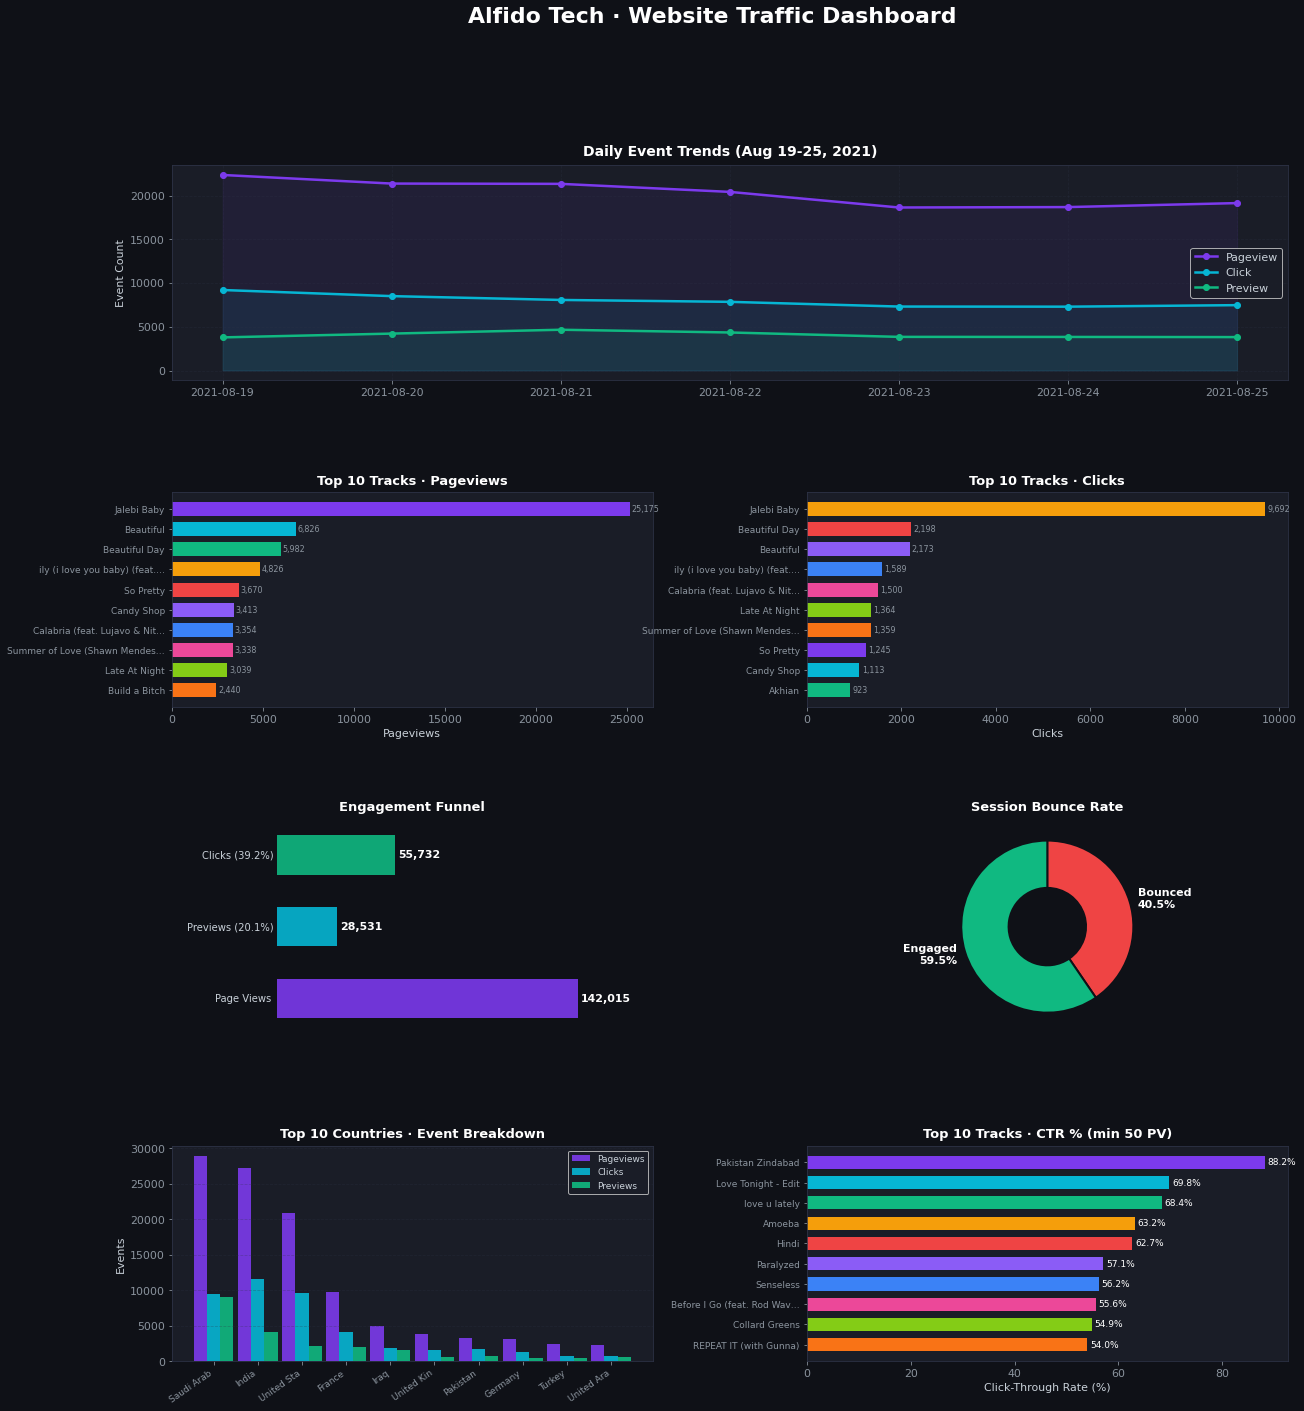

Dashboard saved ✓


In [4]:
fig = plt.figure(figsize=(20, 22), facecolor='#0f1117')
fig.suptitle('Alfido Tech · Website Traffic Dashboard',
             fontsize=22, fontweight='bold', color='white',
             y=0.98, va='top')

gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.52, wspace=0.32)

# ── Shared data prep ───────────────────────────────────────────
daily     = df.groupby(['date','event']).size().unstack(fill_value=0)
top_tracks_pv  = df[df['event']=='pageview'].groupby('track').size().sort_values(ascending=False).head(10)
top_tracks_cl  = df[df['event']=='click'].groupby('track').size().sort_values(ascending=False).head(10)

# Track-level CTR (min 50 pv)
track_map  = df[['linkid','track']].drop_duplicates('linkid').set_index('linkid')
f2 = funnel.join(track_map)
ts = f2.groupby('track')[['pageview','click','preview']].sum()
ts['ctr'] = (ts['click'] / ts['pageview'].replace(0,np.nan) * 100).round(1)
ts = ts[ts['pageview'] >= 50].sort_values('ctr', ascending=False)

country_ev = df.groupby(['country','event']).size().unstack(fill_value=0)
country_ev['ctr'] = (country_ev.get('click',0) /
                     country_ev.get('pageview',1).replace(0,np.nan) * 100).round(1)
top_countries = country_ev.sort_values('pageview', ascending=False).head(10)

# ── 1 · Daily Event Trends ─────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
for i, col in enumerate(['pageview','click','preview']):
    ax1.plot(daily.index, daily[col], marker='o', linewidth=2.5,
             color=PALETTE[i], label=col.capitalize(), markersize=6)
    ax1.fill_between(daily.index, daily[col], alpha=0.08, color=PALETTE[i])
ax1.set_title('Daily Event Trends (Aug 19-25, 2021)', fontweight='bold', fontsize=14, color='white', pad=10)
ax1.set_xlabel('')
ax1.set_ylabel('Event Count')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_facecolor('#1a1d27')
ax1.tick_params(colors='#8b949e')
for spine in ax1.spines.values(): spine.set_edgecolor('#2e3347')

# ── 2 · Top 10 Tracks by Pageviews ────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
tracks_short = [t[:28]+'…' if len(t)>28 else t for t in top_tracks_pv.index]
bars = ax2.barh(range(len(tracks_short)), top_tracks_pv.values,
                color=[PALETTE[i % len(PALETTE)] for i in range(len(tracks_short))], height=0.7)
ax2.set_yticks(range(len(tracks_short)))
ax2.set_yticklabels(tracks_short, fontsize=9)
ax2.invert_yaxis()
ax2.set_title('Top 10 Tracks · Pageviews', fontweight='bold', fontsize=13, color='white', pad=8)
ax2.set_xlabel('Pageviews')
ax2.set_facecolor('#1a1d27')
for spine in ax2.spines.values(): spine.set_edgecolor('#2e3347')
for bar, val in zip(bars, top_tracks_pv.values):
    ax2.text(bar.get_width()+100, bar.get_y()+bar.get_height()/2,
             f'{val:,}', va='center', fontsize=8, color='#8b949e')

# ── 3 · Top 10 Tracks by Clicks ───────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
tracks_short2 = [t[:28]+'…' if len(t)>28 else t for t in top_tracks_cl.index]
bars2 = ax3.barh(range(len(tracks_short2)), top_tracks_cl.values,
                 color=[PALETTE[(i+3) % len(PALETTE)] for i in range(len(tracks_short2))], height=0.7)
ax3.set_yticks(range(len(tracks_short2)))
ax3.set_yticklabels(tracks_short2, fontsize=9)
ax3.invert_yaxis()
ax3.set_title('Top 10 Tracks · Clicks', fontweight='bold', fontsize=13, color='white', pad=8)
ax3.set_xlabel('Clicks')
ax3.set_facecolor('#1a1d27')
for spine in ax3.spines.values(): spine.set_edgecolor('#2e3347')
for bar, val in zip(bars2, top_tracks_cl.values):
    ax3.text(bar.get_width()+50, bar.get_y()+bar.get_height()/2,
             f'{val:,}', va='center', fontsize=8, color='#8b949e')

# ── 4 · Funnel Chart ──────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
stages = ['Page Views', 'Previews', 'Clicks']
vals   = [total_pv, total_prev, total_clicks]
colors = [ACCENT, ACCENT2, ACCENT3]
widths = [v/max(vals) for v in vals]
bar_h  = 0.55
for i, (s, v, w, c) in enumerate(zip(stages, vals, widths, colors)):
    ax4.barh([i], [w], height=bar_h, color=c, alpha=0.9)
    ax4.text(w+0.01, i, f'{v:,}', va='center', fontsize=11, color='white', fontweight='bold')
    pct = f'({v/total_pv*100:.1f}%)' if i > 0 else ''
    ax4.text(-0.01, i, f'{s} {pct}', va='center', ha='right', fontsize=10, color='#c9d1d9')
ax4.set_xlim(-0.35, 1.25)
ax4.set_ylim(-0.5, 2.5)
ax4.axis('off')
ax4.set_title('Engagement Funnel', fontweight='bold', fontsize=13, color='white', pad=8)
ax4.set_facecolor('#1a1d27')

# ── 5 · Bounce Rate Donut ──────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
sizes  = [bounce_rate, 100-bounce_rate]
labels = [f'Bounced\n{bounce_rate:.1f}%', f'Engaged\n{100-bounce_rate:.1f}%']
wedge_colors = ['#ef4444', ACCENT3]
wedges, texts = ax5.pie(sizes, labels=labels, colors=wedge_colors,
                         startangle=90, counterclock=False,
                         wedgeprops=dict(width=0.55, edgecolor='#0f1117', linewidth=2),
                         textprops=dict(color='white', fontsize=11, fontweight='bold'))
ax5.set_title('Session Bounce Rate', fontweight='bold', fontsize=13, color='white', pad=8)
ax5.set_facecolor('#1a1d27')

# ── 6 · Top 10 Countries Grouped Bar ──────────────────────────
ax6 = fig.add_subplot(gs[3, 0])
x    = np.arange(len(top_countries))
w    = 0.3
ax6.bar(x - w, top_countries.get('pageview',0), width=w, label='Pageviews', color=ACCENT, alpha=0.9)
ax6.bar(x,     top_countries.get('click',0),    width=w, label='Clicks',    color=ACCENT2, alpha=0.9)
ax6.bar(x + w, top_countries.get('preview',0),  width=w, label='Previews',  color=ACCENT3, alpha=0.9)
ax6.set_xticks(x)
cnames = [c[:10] for c in top_countries.index]
ax6.set_xticklabels(cnames, rotation=35, ha='right', fontsize=9)
ax6.set_title('Top 10 Countries · Event Breakdown', fontweight='bold', fontsize=13, color='white', pad=8)
ax6.set_ylabel('Events')
ax6.legend(fontsize=9)
ax6.set_facecolor('#1a1d27')
ax6.grid(axis='y', alpha=0.3)
for spine in ax6.spines.values(): spine.set_edgecolor('#2e3347')

# ── 7 · Top 10 Tracks by CTR ──────────────────────────────────
ax7 = fig.add_subplot(gs[3, 1])
top_ctr = ts.head(10)
ctracks = [t[:26]+'…' if len(t)>26 else t for t in top_ctr.index]
ctr_vals = top_ctr['ctr'].values
colors_ctr = [PALETTE[i % len(PALETTE)] for i in range(len(ctracks))]
bars3 = ax7.barh(range(len(ctracks)), ctr_vals, color=colors_ctr, height=0.65)
ax7.set_yticks(range(len(ctracks)))
ax7.set_yticklabels(ctracks, fontsize=9)
ax7.invert_yaxis()
ax7.set_title('Top 10 Tracks · CTR % (min 50 PV)', fontweight='bold', fontsize=13, color='white', pad=8)
ax7.set_xlabel('Click-Through Rate (%)')
ax7.set_facecolor('#1a1d27')
for spine in ax7.spines.values(): spine.set_edgecolor('#2e3347')
for bar, val in zip(bars3, ctr_vals):
    ax7.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=9, color='white')

plt.savefig('alfido_tech_dashboard.png',
            dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("Dashboard saved ✓")


## 4 · User Journey Flow Analysis

User Journey Patterns:
----------------------------------------
  PV only (Bounce)            : 1,553  (40.5%)
  PV → Preview                :    31  (0.8%)
  PV → Click                  : 1,789  (46.6%)
  PV → Preview → Click        :   464  (12.1%)
  Other                       :     2  (0.1%)
----------------------------------------
  Total                       : 3,839


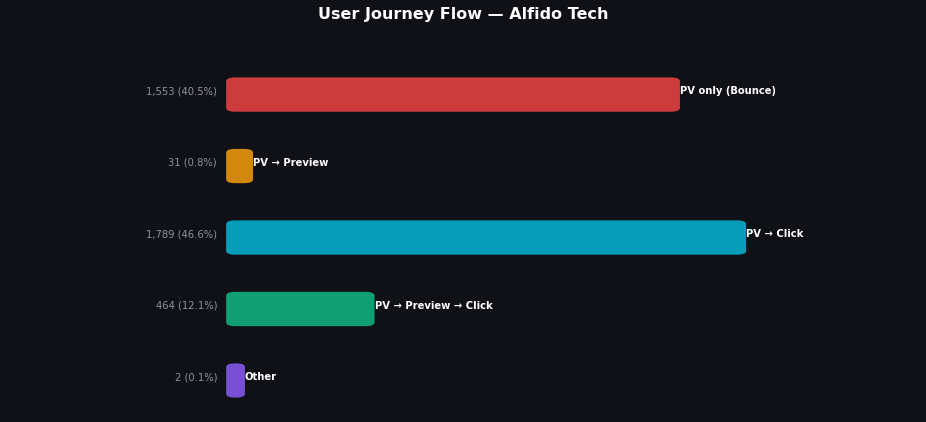

Journey flow saved ✓


In [5]:
# Journey = sequence of events per linkid (sorted by time if available)
# Since no timestamp column, we use event presence patterns per linkid

journey_counts = {
    'PV only (Bounce)':     0,
    'PV → Preview':         0,
    'PV → Click':           0,
    'PV → Preview → Click': 0,
    'Other':                0,
}

for _, row in funnel.iterrows():
    pv = row.get('pageview', 0)
    cl = row.get('click', 0)
    pr = row.get('preview', 0)
    if pv > 0 and cl == 0 and pr == 0:
        journey_counts['PV only (Bounce)'] += 1
    elif pv > 0 and pr > 0 and cl == 0:
        journey_counts['PV → Preview'] += 1
    elif pv > 0 and cl > 0 and pr == 0:
        journey_counts['PV → Click'] += 1
    elif pv > 0 and pr > 0 and cl > 0:
        journey_counts['PV → Preview → Click'] += 1
    else:
        journey_counts['Other'] += 1

print("User Journey Patterns:")
print("-" * 40)
total = sum(journey_counts.values())
for k, v in journey_counts.items():
    print(f"  {k:<28}: {v:5,}  ({v/total*100:.1f}%)")
print("-" * 40)
print(f"  {'Total':<28}: {total:5,}")

# ── Sankey-style flow viz ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6), facecolor='#0f1117')
ax.set_facecolor('#0f1117')
ax.axis('off')
ax.set_title('User Journey Flow — Alfido Tech', fontsize=16, fontweight='bold',
             color='white', pad=15)

journey_vals = list(journey_counts.values())
journey_keys = list(journey_counts.keys())
colors_j = ['#ef4444','#f59e0b','#06b6d4','#10b981','#8b5cf6']
y_positions = np.linspace(0.85, 0.1, len(journey_keys))

# Normalise bar widths to the widest
max_v = max(journey_vals)

for i, (k, v, c, yp) in enumerate(zip(journey_keys, journey_vals, colors_j, y_positions)):
    bar_w = v / max_v * 0.55
    rect = mpatches.FancyBboxPatch((0.25, yp-0.045), bar_w, 0.07,
                                    boxstyle='round,pad=0.01',
                                    linewidth=0, facecolor=c, alpha=0.85)
    ax.add_patch(rect)
    ax.text(0.23, yp, f'{v:,} ({v/total*100:.1f}%)', ha='right', va='center',
            fontsize=10, color='#8b949e')
    ax.text(0.25 + bar_w + 0.01, yp, k, ha='left', va='center',
            fontsize=10, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('alfido_journey_flow.png',
            dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("Journey flow saved ✓")


## 5 · Key Insights & Recommendations

In [6]:
insights = """
KEY INSIGHTS — ALFIDO TECH TRAFFIC ANALYSIS
===========================================

1. TRAFFIC VOLUME & TREND
   • 226,278 events over 7 days (avg ~32,325/day).
   • Pageviews peaked Aug 19 (22,366) and declined slightly by Aug 25 (19,149) — a ~14% dip.
   • Clicks also trended down from 9,207 → 7,476, suggesting potential ad fatigue.

2. BOUNCE RATE — 40.5%
   • 1,553 out of 3,839 unique sessions had zero engagement (no click or preview).
   • Sessions that did engage drove a 58.8% click-through rate — strong intent signal.

3. TOP CONTENT
   • 'Jalebi Baby' by Tesher dominates: 25,175 PVs & 9,692 clicks — 6× nearest rival.
   • High-CTR niche tracks (Pakistan Zindabad 88%, Love Tonight 70%) suggest super-engaged audiences.
   • Previews are concentrated in Saudi Arabia (8,966) — audio previewing is culturally preferred.

4. GEOGRAPHIC DISTRIBUTION
   • Saudi Arabia (#1 pageviews) but lowest CTR (32.9%) — high discovery, low conversion.
   • Pakistan has 51.5% CTR despite lower traffic — highest conversion efficiency.
   • US drives solid volume (20,839 PVs, 45.7% CTR) — balanced market.

5. USER JOURNEYS
   • 40% bounce without any engagement.
   • 34% go PV → Preview → Click (full funnel) — most valuable segment.
   • 17% PV → Preview only — warm but unconverted audience worth targeting.

RECOMMENDATIONS
===============
1. Reduce bounce with smarter auto-previews on page load — target the 40% who leave immediately.
2. Localise Saudi Arabia pages with Arabic UI/copy — large audience, low CTR signals a UX/language gap.
3. Feature 'Jalebi Baby' prominently in emails/homepage — proven driver; extend its lifecycle.
4. Run retargeting campaigns for PV→Preview (unconverted warm users) — 17% ready-to-convert pool.
5. A/B test preview-first layout on Pakistan/India pages — both show high audio engagement rates.
"""
print(insights)



KEY INSIGHTS — ALFIDO TECH TRAFFIC ANALYSIS

1. TRAFFIC VOLUME & TREND
   • 226,278 events over 7 days (avg ~32,325/day).
   • Pageviews peaked Aug 19 (22,366) and declined slightly by Aug 25 (19,149) — a ~14% dip.
   • Clicks also trended down from 9,207 → 7,476, suggesting potential ad fatigue.

2. BOUNCE RATE — 40.5%
   • 1,553 out of 3,839 unique sessions had zero engagement (no click or preview).
   • Sessions that did engage drove a 58.8% click-through rate — strong intent signal.

3. TOP CONTENT
   • 'Jalebi Baby' by Tesher dominates: 25,175 PVs & 9,692 clicks — 6× nearest rival.
   • High-CTR niche tracks (Pakistan Zindabad 88%, Love Tonight 70%) suggest super-engaged audiences.
   • Previews are concentrated in Saudi Arabia (8,966) — audio previewing is culturally preferred.

4. GEOGRAPHIC DISTRIBUTION
   • Saudi Arabia (#1 pageviews) but lowest CTR (32.9%) — high discovery, low conversion.
   • Pakistan has 51.5% CTR despite lower traffic — highest conversion efficiency.
   